## FX spots

 Goal is to monitor and manage the portfolio’s exposures to different risk factors, ensuring that the FX positions are aligned with our risk tolerance. The key exposures are:

- Currency Exposure: How much is invested in each currency.
- PnL Exposure: How much profit/loss is tied to FX moves.
- Delta Exposure: Sensitivity of portfolio value to FX rate changes
- VaR (Value-at-Risk): Potential loss due to FX volatility.
- Carry Exposure: Profit/loss from interest rate differentials.
- Correlation Exposure: Risk from correlations between currency pairs.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf

In [73]:
from datetime import datetime
from scipy.stats import norm


In [3]:
%config InlineBackend.figure_format ='retina'
sns.set(style="whitegrid")

In [30]:
# Define tickers for EUR/USD, GBP/USD, and USD/CHF
tickers = ["EURUSD=X", "GBPUSD=X", "USDCHF=X"]
# Download historical data (adjust the period as needed)
data = yf.download(tickers, period="5y", interval="1d")  # 1 year of daily data
# Extract the 'Close' prices
prices = data['Close']

[*********************100%***********************]  3 of 3 completed


<Figure size 1200x600 with 0 Axes>

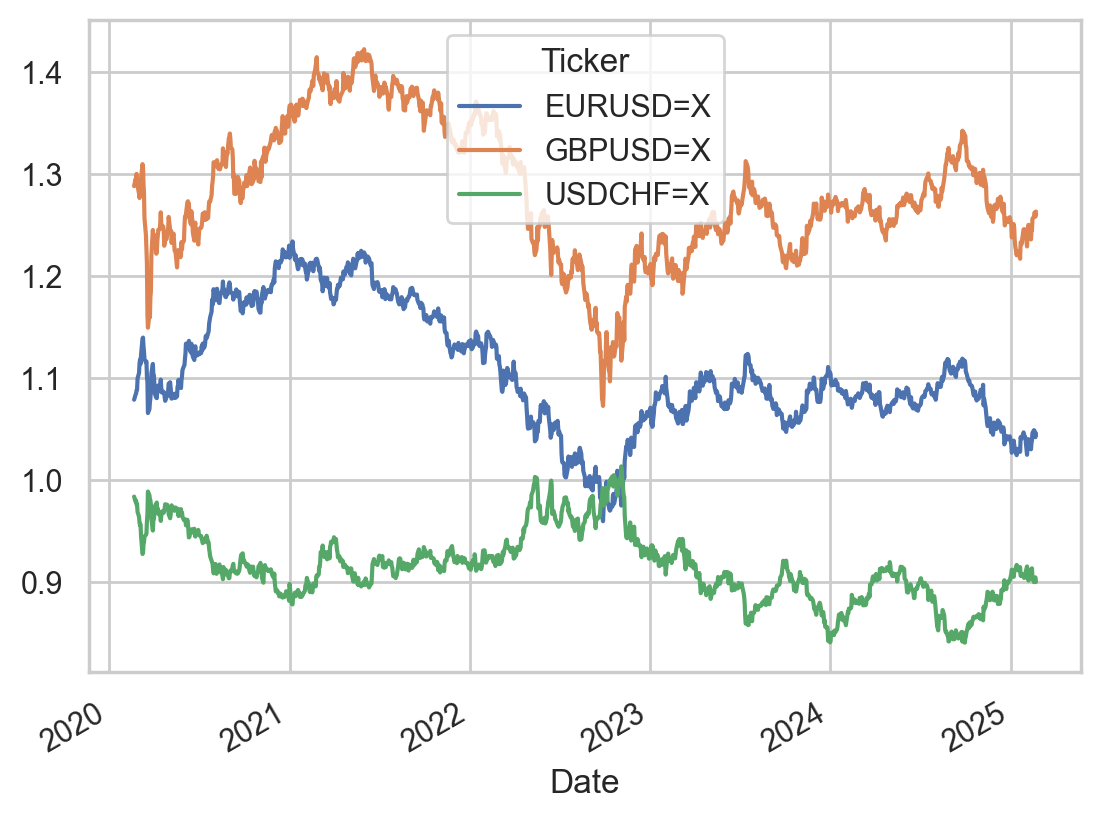

In [43]:
plt.figure(figsize=(12, 6))
prices.plot()
plt.show()

In [42]:
returns = np.log(prices).diff()
# plt.figure(figsize=(12, 6))
# returns.cumsum().plot()
# plt.show()

In [40]:
prices.iloc[-1]

Ticker
EURUSD=X    1.045916
GBPUSD=X    1.263440
USDCHF=X    0.900140
Name: 2025-02-21 00:00:00, dtype: float64

In [54]:
# Define tickers for EUR/USD, GBP/USD, and USD/CHF
tickers = ["EURCHF=X", "GBPCHF=X", "USDCHF=X"]
# Download historical data (adjust the period as needed)
data = yf.download(tickers, period="5y", interval="1d")  # 1 year of daily data
# Extract the 'Close' prices
prices = data['Close']

[*********************100%***********************]  3 of 3 completed


<Figure size 1200x600 with 0 Axes>

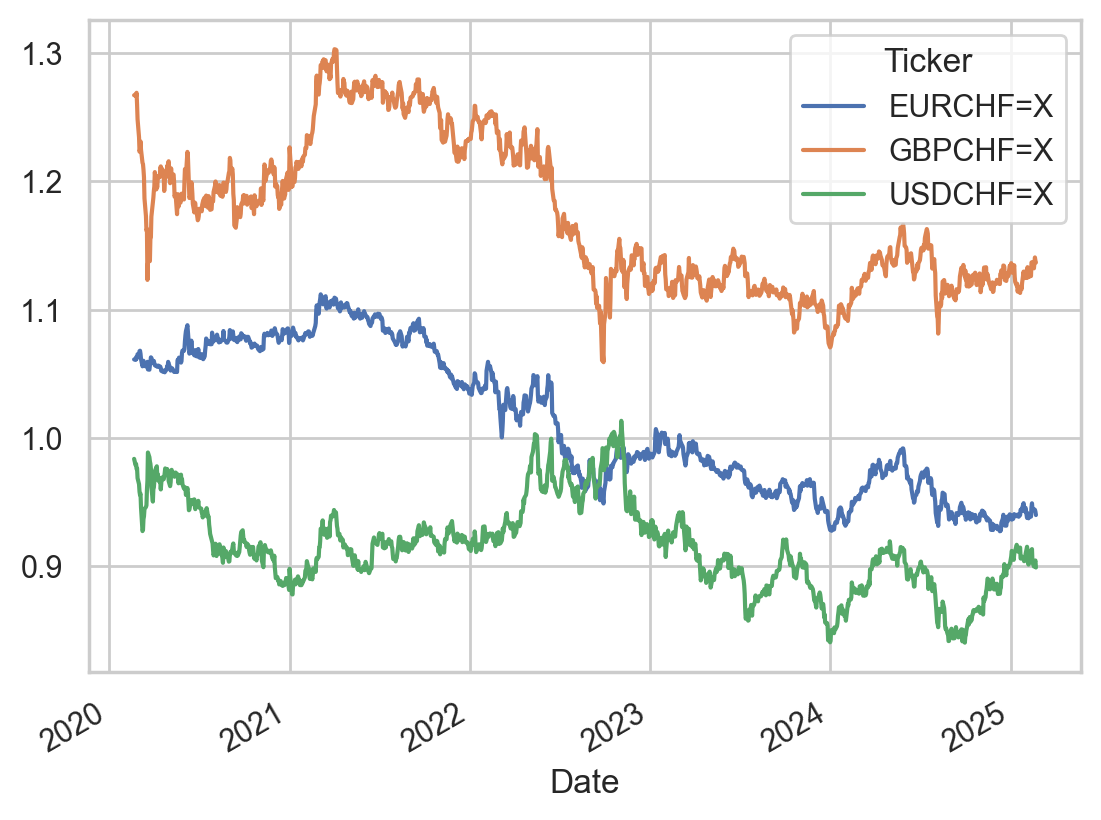

In [55]:
plt.figure(figsize=(12, 6))
prices.plot()
plt.show()

In [56]:
prices.iloc[-1]

Ticker
EURCHF=X    0.93997
GBPCHF=X    1.13684
USDCHF=X    0.89908
Name: 2025-02-21 00:00:00, dtype: float64

## 1. Define FX portfolio and positions

Let's consider a CHF base client, with a portfolio of 10 million CHF, with the following allocations:
- 50% in USD -> 5M CHF in USD
- 25% in EUR -> 2.5M CHF in EUR
- 25% in GBP -> 2.5M CHF in GBP

Given a hedge ration HR=0.5, the client will hedge 50% of the exposure, meaning some currency risk will remain open.

## 2. Convert positions into Foreign Currency amounts

We need to calculate the nominal foreign currency exposure using live FX spot rates 

In [75]:
# Step 1: Portfolio Allocation (in CHF)
portfolio_chf = 10_000_000  # Total portfolio value in CHF
allocation = {'USD': 0.5, 'EUR': 0.25, 'GBP': 0.25}

# Step 2: Market Spot Rates (Assumed)
spot_rates = {'USD': 0.89, 'EUR': 0.96, 'GBP': 1.14}  # CHF per foreign currency unit

# Compute nominal foreign currency exposure
nominal_exposure = {ccy: (portfolio_chf * allocation[ccy]) / spot_rates[ccy] for ccy in allocation}
nominal_exposure

{'USD': 5617977.528089887, 'EUR': 2604166.666666667, 'GBP': 2192982.456140351}

These are the initial unhedged positions in the respective currencies.

Note: 
$\text{FX Exposure} = \text{Nominal Amount} \times \text{Spot Rate}$

so the total CHF exposure remains 10M CHF.


In [77]:
# Compute CHF exposure
chf_exposure = {ccy: nominal_exposure[ccy] * spot_rates[ccy] for ccy in allocation}
chf_exposure

{'USD': 5000000.0, 'EUR': 2500000.0, 'GBP': 2500000.0}

## 3. Hedging

We could hedge using FX forwrads of FX options, buying puts on USD, EUR and GBP. 

CHF notional = Hedge amount * forward rate

In [70]:
# Step 3: Hedging (HR = 0.5)
hedge_ratio = 0.5
hedged_amount = {ccy: chf_exposure[ccy] * hedge_ratio for ccy in allocation}
unhedged_amount = {ccy: chf_exposure[ccy] * (1 - hedge_ratio) for ccy in allocation}


Nominal Foreign Currency Exposure: {'USD': 5617977.528089887, 'EUR': 2604166.666666667, 'GBP': 2192982.456140351}
CHF Exposure: {'USD': 5000000.0, 'EUR': 2500000.0, 'GBP': 2500000.0}
Hedged Amount (CHF): {'USD': 2500000.0, 'EUR': 1250000.0, 'GBP': 1250000.0}
Unhedged Amount (CHF): {'USD': 2500000.0, 'EUR': 1250000.0, 'GBP': 1250000.0}
Individual Currency VaR (CHF): {'USD': 24672.80440427208, 'EUR': 10280.3351684467, 'GBP': 13364.435718980709}
Portfolio VaR (CHF, 95% confidence): 39881.87


In [71]:
nominal_exposure

{'USD': 5617977.528089887, 'EUR': 2604166.666666667, 'GBP': 2192982.456140351}

## 4. Risk

In [78]:
# Step 4: Risk Calculations (Assumed Volatilities & Correlations)
daily_vol = {'USD': 0.006, 'EUR': 0.005, 'GBP': 0.0065}  # Daily volatilities
correlation_matrix = np.array([[1.0, 0.4, 0.5], [0.4, 1.0, 0.6], [0.5, 0.6, 1.0]])
currencies = ['USD', 'EUR', 'GBP']

# Compute individual currency VaR (1-day, 95% confidence)
var_individual = {ccy: norm.ppf(0.95) * unhedged_amount[ccy] * daily_vol[ccy] for ccy in allocation}

# Compute Portfolio VaR (considering correlations)
weights = np.array([unhedged_amount[ccy] for ccy in currencies])
weights = weights / sum(weights)  # Normalize weights
cov_matrix = np.outer(list(daily_vol.values()), list(daily_vol.values())) * correlation_matrix
portfolio_var = np.sqrt(weights.T @ cov_matrix @ weights) * norm.ppf(0.95) * sum(unhedged_amount.values())

In [79]:
# Step 5: Print Results
print("Nominal Foreign Currency Exposure:", nominal_exposure)
print("CHF Exposure:", chf_exposure)
print("Hedged Amount (CHF):", hedged_amount)
print("Unhedged Amount (CHF):", unhedged_amount)
print("Individual Currency VaR (CHF):", var_individual)
print(f"Portfolio VaR (CHF, 95% confidence): {portfolio_var:.2f}")

Nominal Foreign Currency Exposure: {'USD': 5617977.528089887, 'EUR': 2604166.666666667, 'GBP': 2192982.456140351}
CHF Exposure: {'USD': 5000000.0, 'EUR': 2500000.0, 'GBP': 2500000.0}
Hedged Amount (CHF): {'USD': 2500000.0, 'EUR': 1250000.0, 'GBP': 1250000.0}
Unhedged Amount (CHF): {'USD': 2500000.0, 'EUR': 1250000.0, 'GBP': 1250000.0}
Individual Currency VaR (CHF): {'USD': 24672.80440427208, 'EUR': 10280.3351684467, 'GBP': 13364.435718980709}
Portfolio VaR (CHF, 95% confidence): 39881.87
